In [3]:
import numpy
import torch
import random

In [4]:
words = open('names.txt', 'r').read().splitlines()

In [5]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [6]:
N = torch.zeros(27, 27, dtype=torch.int32)

In [7]:
strtoi = {}
for i in range(26):
    c = chr(97+i)
    strtoi[c] = i+1
strtoi["."] = 0

In [8]:
itostr = {i[1]: i[0] for i in strtoi.items()}

In [12]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for xi1, xi2 in zip(chs, chs[1:]):
        index1 = strtoi[xi1]
        index2 = strtoi[xi2]
        N[index1, index2] += 1
        

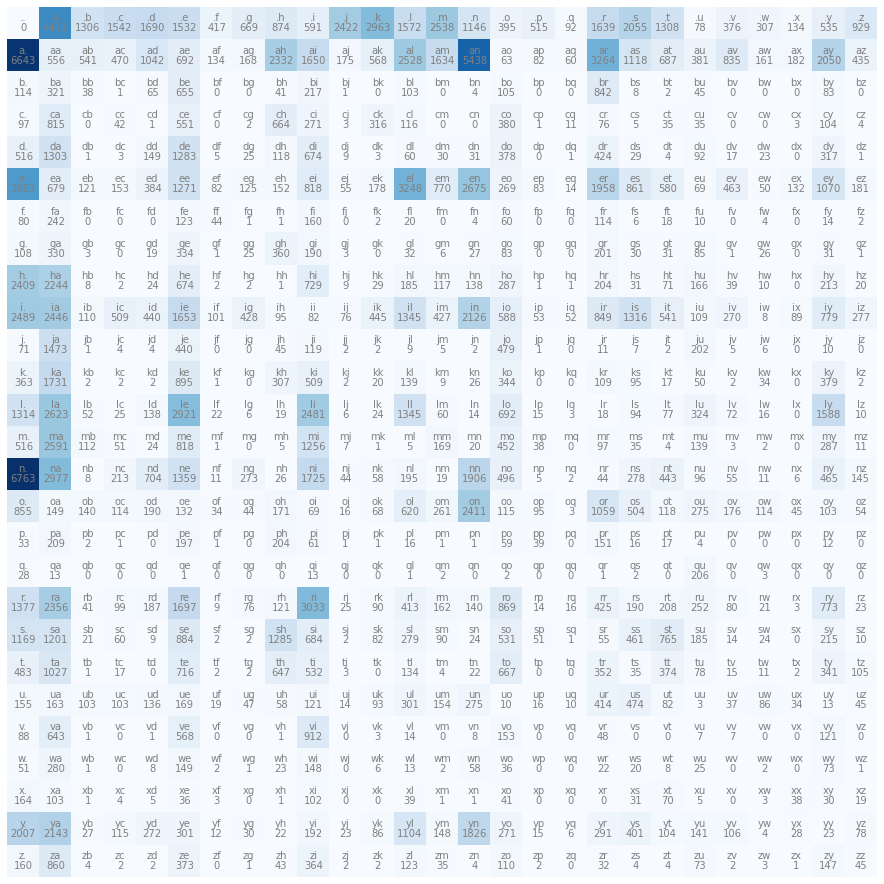

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itostr[i] + itostr[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');



In [43]:
P.sum(1).shape

torch.Size([27])

In [50]:
# get the probability matrix, with smoothing
P = (N+1).float()
P /= P.sum(1, keepdims=True)

In [47]:
P.shape

torch.Size([27, 27])

In [51]:
# lets sample the next letter based on the probabilities
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    res = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        s = itostr[ix]
        if ix == 0:
            break
        res.append(s)
        
    
    print("".join(res))
        

cexze
momasurailezitynn
konimittain
llayn
ka


In [57]:
# get the log probs, and then make it negative, and then average
log_likelihood = 0.0
count = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for xi1, xi2 in zip(chs, chs[1:]):
        index1 = strtoi[xi1]
        index2 = strtoi[xi2]
        prob = P[index1, index2]
        log_prob = torch.log(prob)
        log_likelihood += log_prob
        count += 1
# loss
(-log_likelihood / count).item()

2.454289674758911

In [211]:
# time to make it into a neural network
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, dtype=torch.float32, requires_grad=True)

xs = []
ys = []

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for xi1, xi2 in zip(chs, chs[1:]):
        index1 = strtoi[xi1]
        index2 = strtoi[xi2]
        xs.append(index1)
        ys.append(index2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [212]:
import torch.nn.functional as F

In [213]:
# forward pass is element wise multiplication, but needs to be in encoded first

# encoding
xenc = F.one_hot(xs, num_classes=27).float()

In [214]:
logits = xenc @ W

In [215]:
# ^^^ these are log counts
N = torch.exp(logits)

In [216]:
# get the probs
P = N
P /= P.sum(1, keepdims=True)

In [217]:
# what's the loss function??
# let me use the expected values
log_prob = torch.log(P)
neg_log = -log_prob
average_neg_log = neg_log.mean()
average_neg_log.item()

3.755749225616455

In [218]:
loss = -P[torch.arange(5), ys].log().mean()
loss

tensor(3.7693, grad_fn=<NegBackward0>)

In [220]:
# bring this back to work on entire dataset
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, dtype=torch.float32, requires_grad=True)

xs = []
ys = []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for xi1, xi2 in zip(chs, chs[1:]):
        index1 = strtoi[xi1]
        index2 = strtoi[xi2]
        xs.append(index1)
        ys.append(index2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num_names = xs.numel()

In [298]:
# make it all in one
for _ in range(5):
    xenc = F.one_hot(xs, num_classes=27).float()
    
    # Forward Pass
    logits = xenc @ W
    N = torch.exp(logits)
    P = N / N.sum(1, keepdims=True)
    loss = -P[torch.arange(num_names), ys].log().mean()
    
    # Zero grad
    W.grad = None
    
    # Backprop
    loss.backward()
    
    # update weights
    W.data += -10 * W.grad
    

In [300]:
loss # wow, as good as just using the counts lol!!!

tensor(2.4741, grad_fn=<NegBackward0>)